# Supervised Regression mit scikit-learn

## Schritt 1: Werkzeuge laden

In [195]:
import pandas as pd
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from seaborn import pairplot #Extra
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np

## 2. Daten Aufbereiten

In [204]:
file_path = "../data/bikesharing.csv"

data = pd.read_csv(
    file_path,
    sep=";",
    encoding="utf-8",
    low_memory=False,
    skiprows=[0],
    usecols=[1,2,3,5,6,8,9,12],
    nrows=(308))

mapping_season = {"spring": 0, "summer": 1, "fall": 2, "winter": 3}
data["season"] = data["season"].map(mapping_season)

mapping_holiday = {"no": 0, "yes": 1}
data["holiday"] = data["holiday"].map(mapping_holiday)

mapping_weekday = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu": 3, "Fri": 4, "Sat": 5, "Sun": 6}
data["weekday"] = data["weekday"].map(mapping_weekday)

mapping_weathersit = {"cloudy": 0, "clear sky": 1, "light rain": 2}
data["weathersit"] = data["weathersit"].map(mapping_weathersit)

data["temp"] = data["temp"].fillna(data["temp"].median())

data["hum"] = data["hum"].fillna(data["hum"].median())

data["windspeed"] = data["windspeed"].fillna(data["windspeed"].median())

data["cnt"] = data["cnt"].fillna(data["cnt"].median())

data

,season,holiday,weekday,weathersit,temp,hum,windspeed,cnt
0,0,0,5,0,0.344167,0.805833,0.160446,985.0
1,0,0,6,0,0.363478,0.647709,0.248539,801.0
2,0,0,0,1,0.196364,0.437273,0.248309,1349.0
3,0,0,1,1,0.200000,0.590435,0.160296,1562.0
4,0,0,2,1,0.538333,0.436957,0.186900,1600.0
...,...,...,...,...,...,...,...,...
303,3,0,0,1,0.340000,0.703333,0.106350,3669.0
304,3,0,1,1,0.400833,0.683750,0.135571,4068.0
305,3,0,2,1,0.377500,0.718750,0.082092,4186.0
306,3,0,3,1,0.408333,0.702083,0.136817,3974.0


In [205]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      308 non-null    int64  
 1   holiday     308 non-null    int64  
 2   weekday     308 non-null    int64  
 3   weathersit  308 non-null    int64  
 4   temp        308 non-null    float64
 5   hum         308 non-null    float64
 6   windspeed   308 non-null    float64
 7   cnt         308 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 19.4 KB


In [206]:
list(data)

['season',
 'holiday',
 'weekday',
 'weathersit',
 'temp',
 'hum',
 'windspeed',
 'cnt']

## 3. Daten explorieren

In [207]:
data.head()

,season,holiday,weekday,weathersit,temp,hum,windspeed,cnt
0,0,0,5,0,0.344167,0.805833,0.160446,985.0
1,0,0,6,0,0.363478,0.647709,0.248539,801.0
2,0,0,0,1,0.196364,0.437273,0.248309,1349.0
3,0,0,1,1,0.200000,0.590435,0.160296,1562.0
4,0,0,2,1,0.538333,0.436957,0.186900,1600.0


In [208]:
data.tail()

,season,holiday,weekday,weathersit,temp,hum,windspeed,cnt
303,3,0,0,1,0.340000,0.703333,0.106350,3669.0
304,3,0,1,1,0.400833,0.683750,0.135571,4068.0
305,3,0,2,1,0.377500,0.718750,0.082092,4186.0
306,3,0,3,1,0.408333,0.702083,0.136817,3974.0
307,3,0,4,0,0.403333,0.622500,0.271779,4046.0


In [209]:
data.describe()

,season,holiday,weekday,weathersit,temp,hum,windspeed,cnt
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.00000
mean,1.327922,0.022727,3.000000,0.678571,0.510985,0.639998,0.194224,3482.50974
std,1.007916,0.149275,2.003255,0.532888,0.194446,0.149343,0.075551,1433.92675
min,0.000000,0.000000,0.000000,0.000000,0.059130,0.000000,0.022392,431.00000
25%,0.000000,0.000000,1.000000,0.000000,0.341875,0.537894,0.139774,2053.50000
50%,1.000000,0.000000,3.000000,1.000000,0.538333,0.647709,0.186900,3974.00000
75%,2.000000,0.000000,5.000000,1.000000,0.680208,0.740937,0.233947,4668.00000
max,3.000000,1.000000,6.000000,2.000000,0.849167,0.972500,0.507463,6043.00000


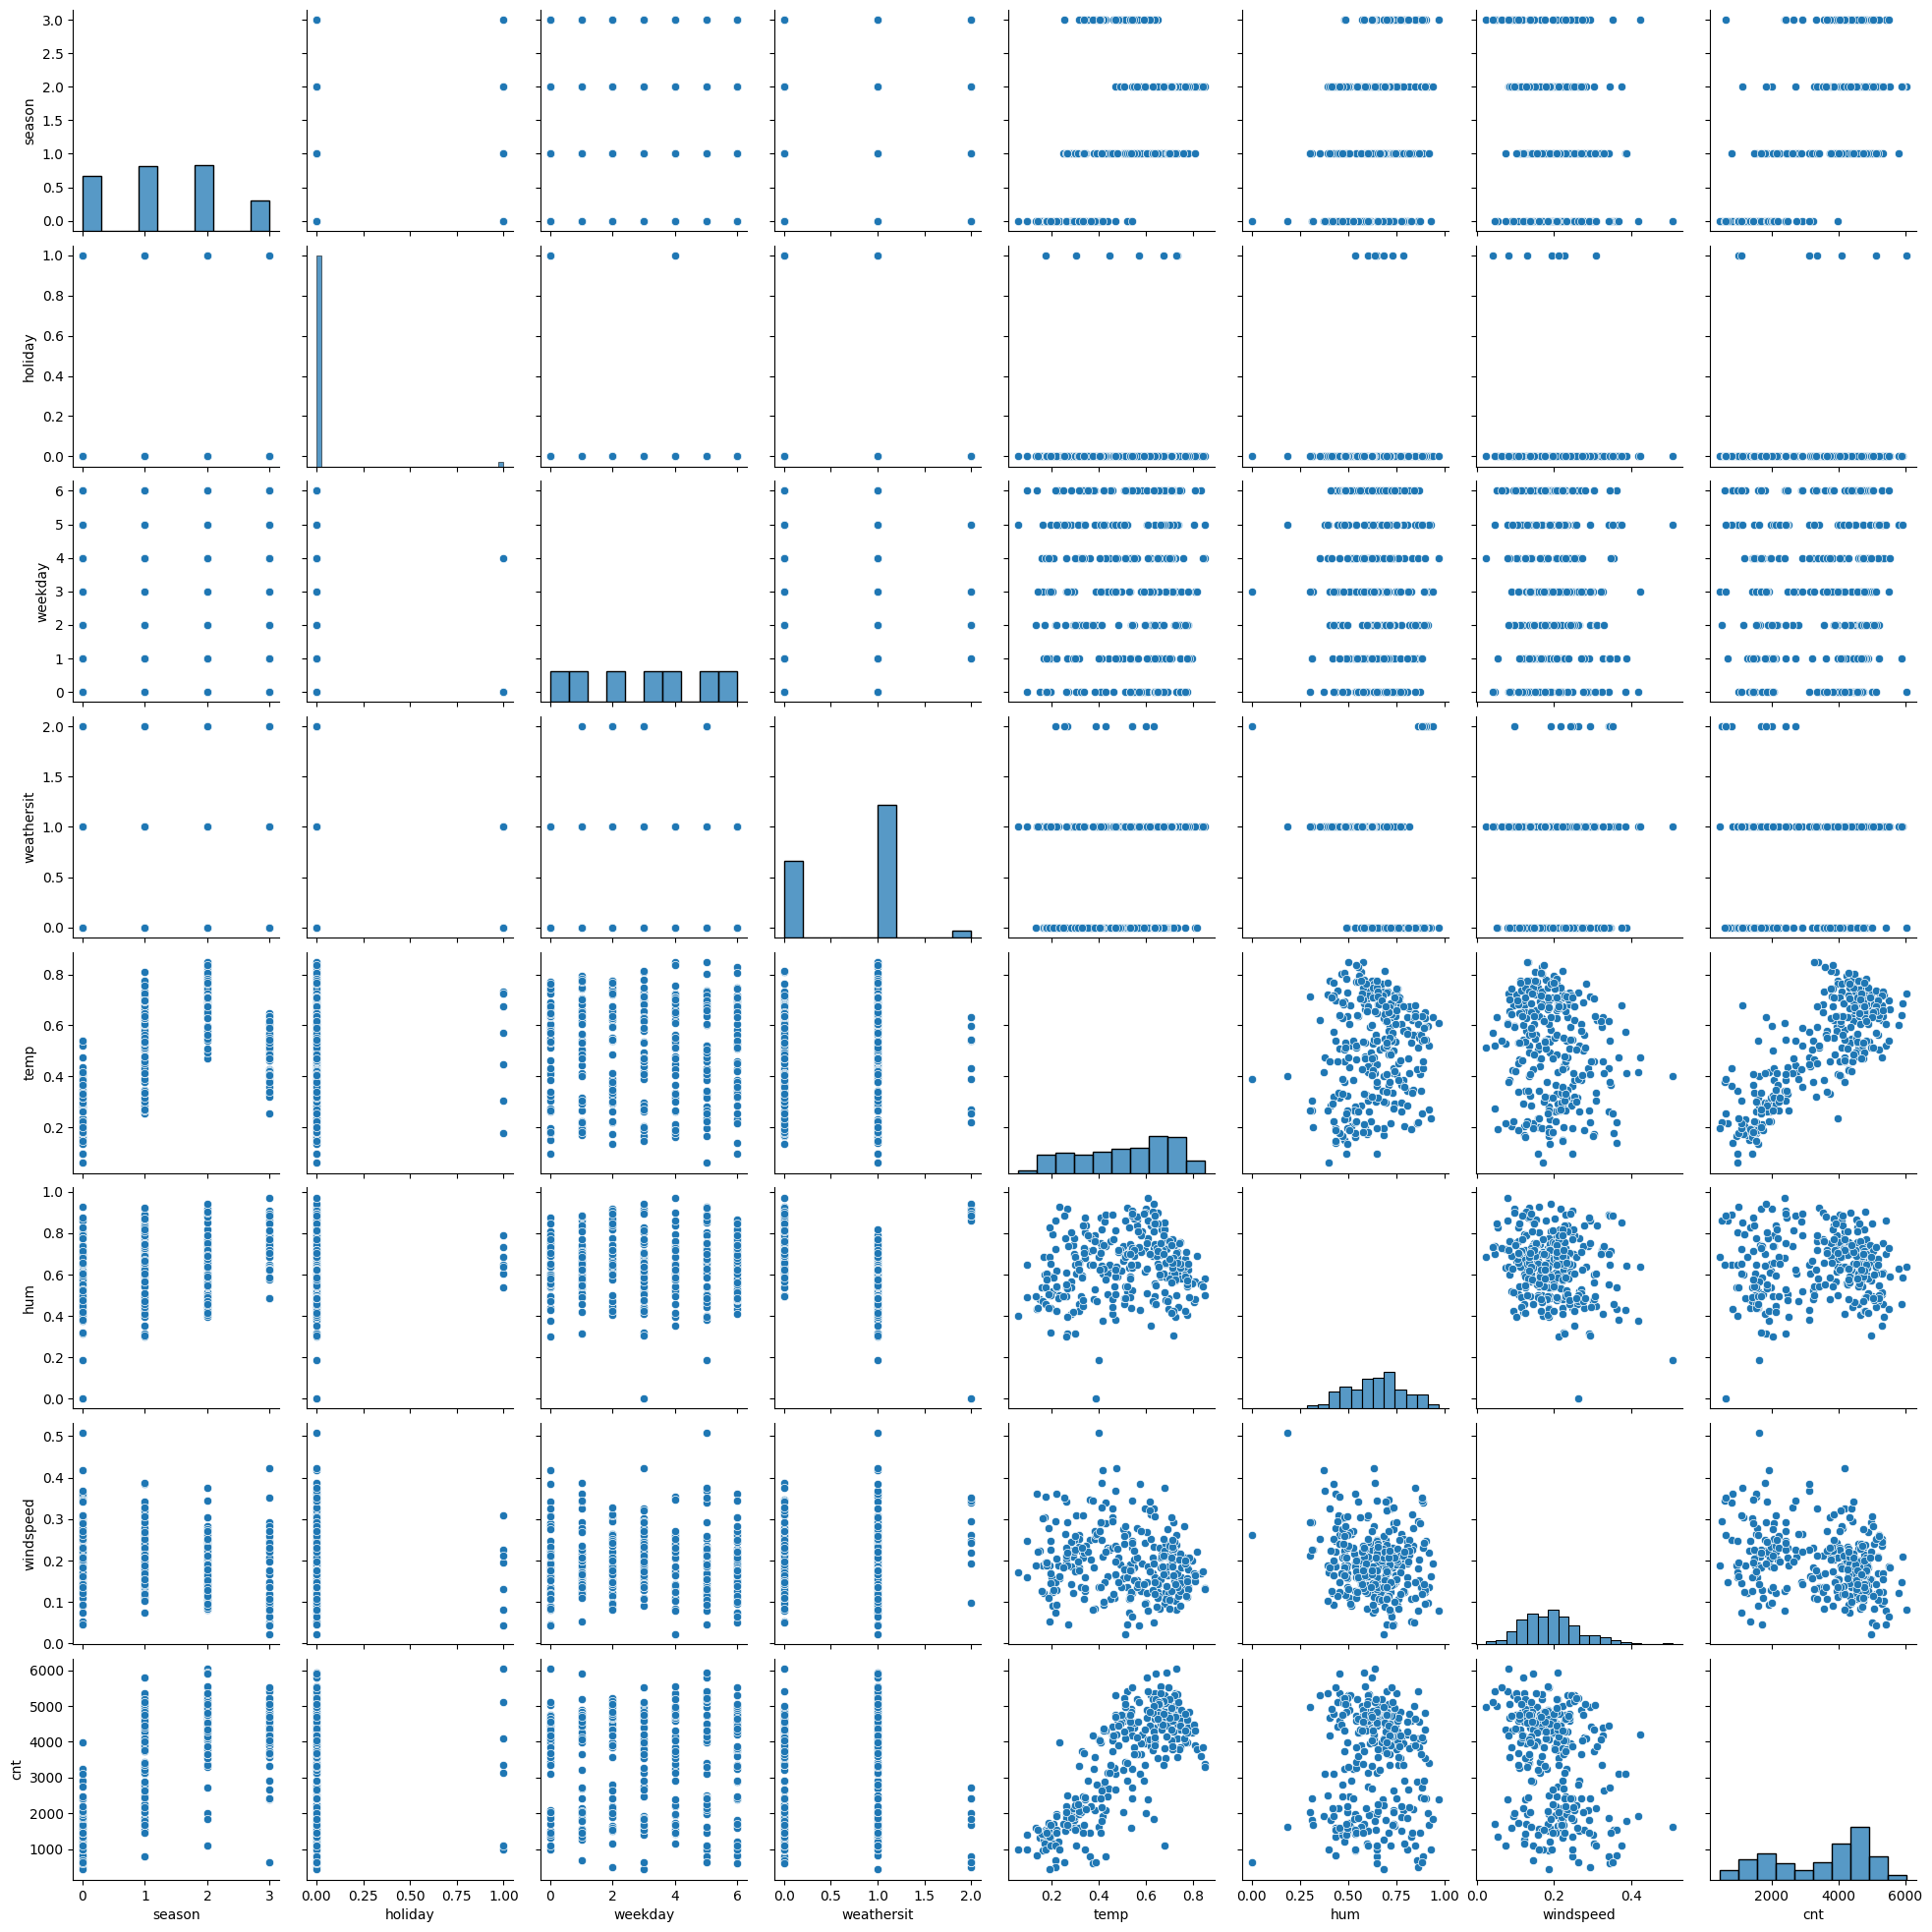

In [210]:
pairplot(data)

<Axes: >

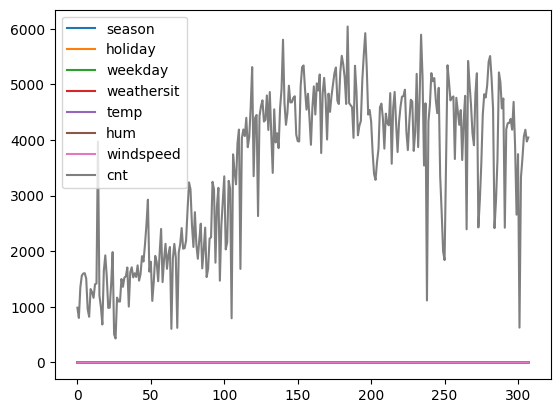

In [211]:
data.plot()

<Axes: >

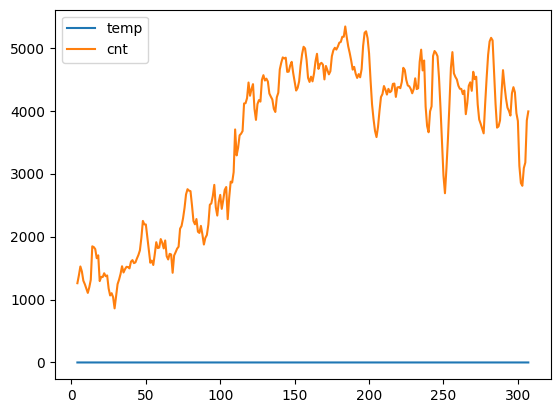

In [212]:
data[["temp","cnt"]].rolling(5).mean().plot()

<Axes: >

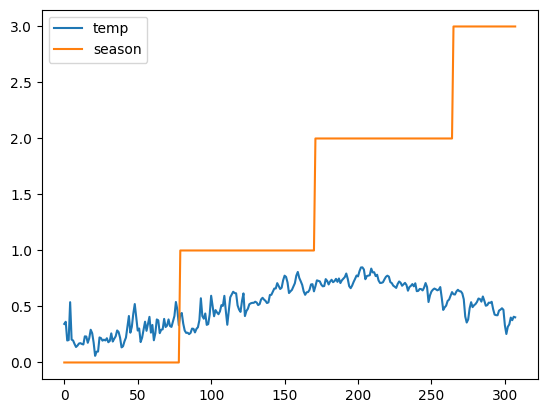

In [213]:
data[["temp","season"]].plot()

<Axes: >

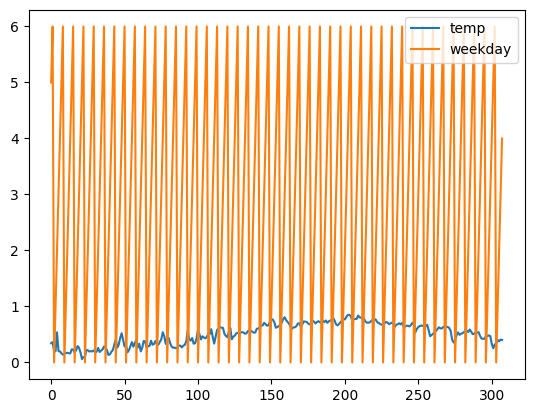

In [214]:
data[["temp","weekday"]].plot()

<Axes: >

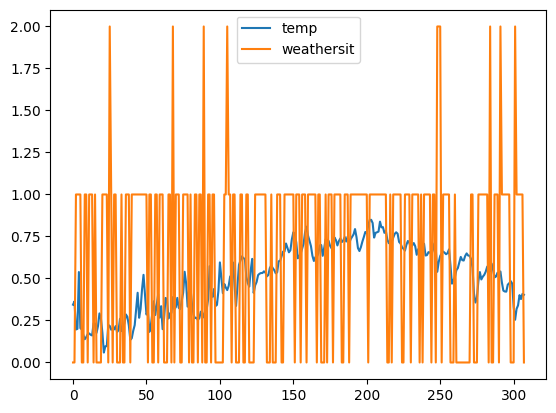

In [215]:
data[["temp","weathersit"]].plot()

<Axes: >

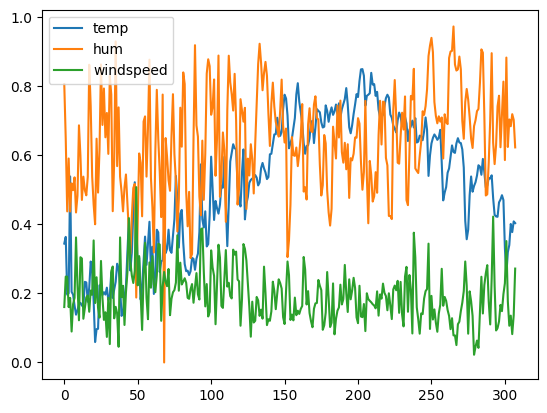

In [216]:
data[["temp","hum", "windspeed"]].plot()

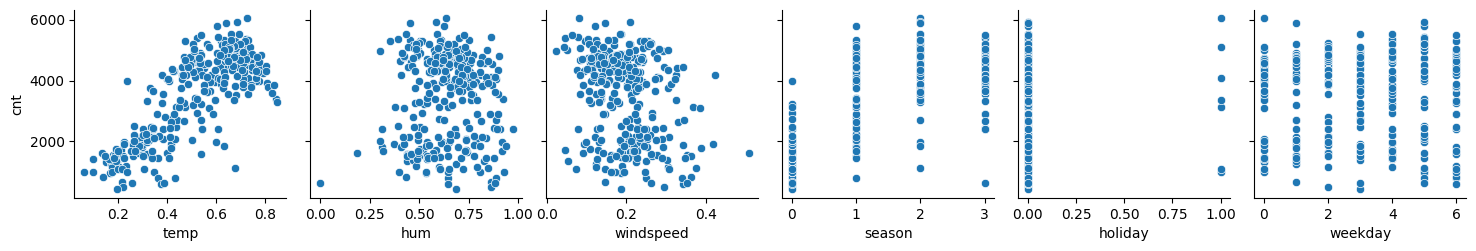

In [217]:
pairplot(data, 
             x_vars=["temp", "hum", "windspeed","season","holiday","weekday",], 
             y_vars=["cnt"])

## Schritt 4: Daten vorbereiten

In [218]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      308 non-null    int64  
 1   holiday     308 non-null    int64  
 2   weekday     308 non-null    int64  
 3   weathersit  308 non-null    int64  
 4   temp        308 non-null    float64
 5   hum         308 non-null    float64
 6   windspeed   308 non-null    float64
 7   cnt         308 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 19.4 KB


In [219]:
X = data[[
 'season',
 'holiday',
 'weekday',
 'weathersit',
 'temp',
 'hum',
 'windspeed']]

y = data[
 'cnt'
 ]

In [220]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)

In [221]:
print("Trainings-Daten", X_train.shape, y_train.shape)
print("Test-Daten", X_test.shape, y_test.shape)

Trainings-Daten (246, 7) (246,)
Test-Daten (62, 7) (62,)


In [222]:
encoder = OneHotEncoder()
scaler = StandardScaler()

In [223]:
numerical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", MinMaxScaler(feature_range=(0, 1))),
        ]
)

categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing"),),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False),),
        ]
)

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_transformer, make_column_selector(dtype_include=[np.number])),
    ("cat", categorical_transformer, make_column_selector(dtype_include=[object, "category"]))
])

In [224]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

In [225]:
X_train.shape, X_train_prep.shape

((246, 7), (246, 7))

## Schritt 5: Machine Learning

In [226]:
tree_regressor = DecisionTreeRegressor()
tree_regressor.fit(X_train_prep, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [231]:
print("F2", r2_score(y_test, tree_regressor.predict(X_test_prep)))
print("MAE", mean_absolute_error(y_test, tree_regressor.predict(X_test_prep)))
print("RMSE", root_mean_squared_error(y_test, tree_regressor.predict(X_test_prep)))

F2 0.7864965611934924
MAE 531.483870967742
RMSE 696.2777764193569


In [233]:
linear_regressor = LinearRegression()
linear_regressor.fit(X_train_prep, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [234]:
print("F2", r2_score(y_test, linear_regressor.predict(X_test_prep)))
print("MAE", mean_absolute_error(y_test, linear_regressor.predict(X_test_prep)))
print("RMSE", root_mean_squared_error(y_test, linear_regressor.predict(X_test_prep)))

F2 0.7853764218880019
MAE 515.812825268007
RMSE 698.1018871144826
